# Primary project: Bitcoin Low with TensorFlow

An attention-based neural regressor built with TensorFlow/Keras: positional encoding, two multi-head attention blocks, Conv1D projections, pooling and a dense head. It uses 180 past days and price/volume indicators. This is one of the three original projects featured in the [README](../README.md).

## Saved result and scope

- Saved final-30-day evaluation: **MAPE 3.40%, MAE USD 2,702.68, RMSE USD 3,138.98**.
- Each test input uses actual observations through the previous day. These are 30 rolling one-step predictions from a fixed trained model, not one forecast issued 30 days earlier.
- Early stopping and learning-rate reduction monitor training loss; this run has no separate validation split. The cell labelled “Backtest” predicts the training windows and is an in-sample diagnostic.
- The future 30-day path is recursive and keeps non-Low inputs fixed. Its future accuracy has not been measured by the saved 3.40% MAPE.
- The saved run used Yahoo Finance BTC-USD daily OHLCV and TensorFlow 2.19.0. Data are downloaded through the current date on rerun, so results can change. The FRED fallback is a different target and is not comparable to daily Low.

## Run

Use a separate Python environment with TensorFlow 2.19.0, pandas, numpy, scikit-learn, matplotlib, Pillow, tqdm, yfinance and pandas-datareader. Run setup once and restart the kernel if packages changed. Internet access is required. Generated model files are ignored by Git. Original saved outputs and modeling logic are retained; the setup and future-chart title have publication edits. Read the [data card](../docs/data.md), [metric details](../docs/preliminary_results.md) and [evaluation designs](../docs/evaluation.md).


In [1]:
# 1. Cài đặt các thư viện cần thiết cho Colab (TensorFlow, Pandas DataReader, v.v.)
try:
    import tensorflow as tf
    import pandas_datareader
    import yfinance
    print("[INFO] TensorFlow version:", tf.__version__)
except ImportError:
    print("[INFO] Đang cài đặt các thư viện thiếu...")
    %pip install "tensorflow==2.19.0" pandas-datareader yfinance
    import tensorflow as tf
    print("[INFO] Đã cài đặt xong TensorFlow version:", tf.__version__)

# 2. Sau khi chạy xong cell này, nếu vẫn gặp lỗi, hãy chọn 'Runtime' -> 'Restart Session'

2026-10-01 14:12:34.773954: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1790863954.989966      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1790863955.044331      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1790863955.521524      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790863955.521560      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790863955.521563      57 computation_placer.cc:177] computation placer alr

[INFO] TensorFlow version: 2.19.0


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import (Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, 
                                     Bidirectional, LSTM, Conv1D, Concatenate, Add, Reshape, 
                                     Flatten, GlobalAveragePooling1D, Attention, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
import matplotlib.pyplot as plt
import yfinance as yf
from pandas_datareader import data as pdr
from datetime import timedelta, datetime
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error
import io
from PIL import Image
from matplotlib.dates import DateFormatter
import zipfile
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras")

In [3]:
# Kiểm tra và cấu hình GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Num GPUs Available:  2


In [4]:
# Hàm tải dữ liệu Bitcoin từ Yahoo Finance (ổn định hơn FRED)
def fetch_btc_data(start, end):
    try:
        print(f"[INFO] Đang tải dữ liệu Bitcoin từ Yahoo Finance...")
        # Sử dụng auto_adjust=True để làm phẳng cột ngay lập tức
        df = yf.download('BTC-USD', start=start, end=end, interval='1d', auto_adjust=True)
        if df.empty:
            raise ValueError("Không nhận được dữ liệu từ Yahoo Finance.")
        return df
    except Exception as e:
        print(f"[ERROR] Lỗi khi tải dữ liệu: {e}")
        # Fallback sang FRED nếu yfinance lỗi
        try:
            print("[INFO] Thử tải dữ liệu từ FRED (Fallback)...")
            df = pdr.DataReader('CBBTCUSD', 'fred', start, end)
            df.rename(columns={'CBBTCUSD': 'Low'}, inplace=True)
            return df
        except Exception as e2:
            raise ValueError(f"Không thể tải dữ liệu: {e2}")

# Tải dữ liệu
startday = "2014-08-01"
endday = datetime.now().strftime('%Y-%m-%d')
df_raw = fetch_btc_data(startday, endday)

# Đảm bảo các cột được làm phẳng (hết MultiIndex)
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

print(f"[INFO] Danh sách cột đang có: {df_raw.columns.tolist()}")
print(f"[INFO] Tải thành công {len(df_raw)} dòng dữ liệu.")
df_raw.tail()

[INFO] Đang tải dữ liệu Bitcoin từ Yahoo Finance...


[*********************100%***********************]  1 of 1 completed

[INFO] Danh sách cột đang có: ['Close', 'High', 'Low', 'Open', 'Volume']
[INFO] Tải thành công 4397 dòng dữ liệu.


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-09-26,84406.453125,84423.179688,83781.109375,84035.820312,15169336375
2026-09-27,84458.085938,85126.109375,84121.328125,84412.718750,19386591468
2026-09-28,83502.609375,84972.664062,82570.718750,84454.117188,42589028679
2026-09-29,83622.429688,84511.281250,82739.093750,83500.320312,28029782264
2026-09-30,83553.851562,85599.804688,82927.875000,83621.398438,36290317874


In [5]:
# ========== NÂNG CẤP FEATURE ENGINEERING (V2 - Thêm Volume) ==========
def add_advanced_features(df):
    df = df.copy()
    
    # 1. Price Changes & Volume handling
    # Thay 'Close' -> 'Low'
    df['returns'] = df['Low'].pct_change()
    df['log_returns'] = np.log(df['Low'] / df['Low'].shift(1))
    
    # Kiểm tra nếu có cột Volume (yfinance có, FRED có thể không)
    has_volume = 'Volume' in df.columns
    if has_volume:
        df['vol_change'] = df['Volume'].pct_change()
        df['Volume_MA7'] = df['Volume'].rolling(window=7).mean()
    else:
        print("[WARNING] Không tìm thấy cột Volume. Sẽ bỏ qua các đặc trưng khối lượng.")
        df['vol_change'] = 0
        df['Volume_MA7'] = 0
    
    # 2. Momentum (RSI) - Tính toán dựa trên giá Low
    delta = df['Low'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-9)
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # MACD - Tính toán dựa trên giá Low
    ema12 = df['Low'].ewm(span=12, adjust=False).mean()
    ema26 = df['Low'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    
    # 3. Trend & Volatility - Tính toán dựa trên giá Low
    df['MA7'] = df['Low'].rolling(window=7).mean()
    df['MA30'] = df['Low'].rolling(window=30).mean()
    df['EMA20'] = df['Low'].ewm(span=20, adjust=False).mean()
    
    # Bollinger Bands - Tính toán dựa trên giá Low
    std20 = df['Low'].rolling(window=20).std()
    df['BB_Upper'] = df['EMA20'] + (std20 * 2)
    df['BB_Lower'] = df['EMA20'] - (std20 * 2)
    
    # 4. Time Features
    df['day_of_week'] = df.index.dayofweek / 6.0
    
    # Drop rows with NaN
    df = df.dropna()
    return df

# Chạy feature engineering
df = add_advanced_features(df_raw)

# Danh sách đặc trưng tối ưu (Tự động loại bỏ Volume nếu không có)
# Quan trọng: 'Low' phải đứng đầu để windowing lấy đúng cột dự báo
features = [
    'Low', 'MA7', 'MA30', 'RSI', 'MACD', 
    'BB_Upper', 'BB_Lower', 'day_of_week'
]
if 'Volume' in df_raw.columns:
    features += ['Volume', 'Volume_MA7', 'vol_change']

print(f"[INFO] Số lượng features sử dụng: {len(features)}")
print(f"[INFO] Các features: {features}")
df[features].tail()

[INFO] Số lượng features sử dụng: 11
[INFO] Các features: ['Low', 'MA7', 'MA30', 'RSI', 'MACD', 'BB_Upper', 'BB_Lower', 'day_of_week', 'Volume', 'Volume_MA7', 'vol_change']


Price,Low,MA7,MA30,RSI,MACD,BB_Upper,BB_Lower,day_of_week,Volume,Volume_MA7,vol_change
Date,,,,,,,,,,,
2026-09-26,83781.109375,82776.694196,78491.571615,70.105351,2440.750093,86278.846240,73125.410505,0.833333,15169336375,3.603139e+10,-0.555393
2026-09-27,84121.328125,83351.344866,78731.970833,73.036125,2495.431757,87091.324545,73154.684534,1.000000,19386591468,3.576380e+10,0.278012
2026-09-28,82570.718750,83594.720982,78904.931510,67.264856,2386.140213,87436.562974,73275.677383,0.000000,42589028679,3.360848e+10,1.196829
2026-09-29,82739.093750,83257.733259,79094.363021,73.321705,2286.752078,87760.521652,73405.618434,0.166667,28029782264,3.178407e+10,-0.341854
2026-09-30,82927.875000,83173.181920,79279.344271,73.539980,2197.883502,87949.808323,73662.961278,0.333333,36290317874,3.038433e+10,0.294706


In [6]:
# ========== CHIA DATA & CHUẨN HÓA (REFINED) ==========
test_days = 30
train_data = df.iloc[:-test_days]
test_data = df.iloc[-test_days:]

# Sử dụng RobustScaler để xử lý tốt hơn các đột biến giá của Bitcoin
scaler = RobustScaler()
scaler.fit(train_data[features])

train_scaled_values = scaler.transform(train_data[features])
test_scaled_values = scaler.transform(test_data[features])

train_scaled = pd.DataFrame(train_scaled_values, columns=features, index=train_data.index)
test_scaled = pd.DataFrame(test_scaled_values, columns=features, index=test_data.index)

# Kết hợp lại để tạo input window cho tập test
df_scaled = pd.concat([train_scaled, test_scaled])

print(f"[INFO] Train data shape: {train_scaled.shape}")
print(f"[INFO] Test data shape: {test_scaled.shape}")

[INFO] Train data shape: (4338, 11)
[INFO] Test data shape: (30, 11)


In [7]:
# ========== TẠO CỬA SỔ DỮ LIỆU (WINDOWING) ==========
window_size = 180
num_features = len(features)

# 1. Sinh X_train, y_train
X_train, y_train = [], []
train_scaled_np = train_scaled.values
for i in range(window_size, len(train_scaled_np)):
    X_train.append(train_scaled_np[i-window_size:i])  # shape: (window_size, num_features)
    y_train.append(train_scaled_np[i, 0])  # 0 là index của cột 'Low'

X_train = np.asarray(X_train)
y_train = np.asarray(y_train)

# 2. Sinh X_test, y_test
# Phần mới - strict walk-forward, không nhìn trước trong test
X_test, y_test = [], []

# Lấy window ban đầu: 30 ngày cuối của TRAIN (trước khi vào test)
# Giả sử df_scaled đã được concat train + test như cũ
start_idx = len(train_scaled) - window_size
current_window = df_scaled.iloc[start_idx : start_idx + window_size].values.copy()

for i in range(len(test_data)):
    # Thêm window hiện tại (chỉ đến ngày trước đó)
    X_test.append(current_window[-window_size:].copy())  # shape (window_size, n_features)
    
    # Target là giá trị thực tế ngày hiện tại (đã scale)
    y_test.append(test_scaled.iloc[i, 0])
    
    # Cập nhật window: bỏ ngày cũ nhất, thêm ngày thực tế vừa qua (như trading thật)
    next_row = test_scaled.iloc[i].values  # toàn bộ features của ngày i trong test
    current_window = np.vstack([current_window[1:], next_row])

# Chuyển thành numpy array như cũ
X_test = np.array(X_test)
y_test = np.array(y_test)


print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}   | y_test shape: {y_test.shape}")

X_train shape: (4158, 180, 11) | y_train shape: (4158,)
X_test shape: (30, 180, 11)   | y_test shape: (30,)


In [8]:
# Positional Encoding
class PositionalEncoding(tf.keras.layers.Layer):
    def call(self, x):
        seq_len = tf.shape(x)[1]
        d_model = tf.shape(x)[2]
        pos = tf.cast(tf.range(seq_len)[:, tf.newaxis], tf.float32)
        i = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
        angle_rates = 1 / tf.pow(10000., (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        angle_rads = pos * angle_rates
        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])
        pos_encoding = tf.concat([sines, cosines], axis=-1)
        pos_encoding = tf.expand_dims(pos_encoding, 0)
        return x + pos_encoding

In [9]:
# def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout):
#     x = Reshape((inputs.shape[1], inputs.shape[2]))(inputs)
#     x = PositionalEncoding()(x)
#     x_norm = LayerNormalization(epsilon=1e-6)(x)
#     attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x_norm, x_norm)
#     attn_output = Dropout(dropout)(attn_output)
#     res = Add()([x, attn_output])
#     x = LayerNormalization(epsilon=1e-6)(res)
    
#     # Simplified ConvLSTM2D to a single layer
#     x_conv = Reshape((res.shape[1], 1, 1,1,res.shape[-1]))(x)
#     x_conv = ConvLSTM3D(filters=ff_dim, kernel_size=(1,1, 1), activation='gelu', return_sequences=True)(x_conv)
#     x_conv = Dropout(dropout)(x_conv)
#     x_conv = Reshape((res.shape[1], ff_dim))(x_conv)
    
#     # Kept Bidirectional LSTM but reduced dropout
#     x_lstm = Bidirectional(LSTM(units=ff_dim//2, return_sequences=True))(x)
#     x_lstm = Dropout(dropout)(x_lstm)
    
#     # Combine ConvLSTM and LSTM outputs
#     x_combined = Concatenate()([x_conv, x_lstm])
    
#     # Simplified to a single Conv1D
#     x = Conv1D(filters=ff_dim, kernel_size=1, activation="gelu")(x_combined)
#     x = Dropout(dropout)(x)
    
#     # Kept final normalization and projection
#     x = LayerNormalization(epsilon=1e-6)(x)
#     x = Dense(units=res.shape[-1], activation="linear")(x)
    
#     return Add()([res, x])

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

# ==================== POSITIONAL ENCODING ====================
class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos_encoding = self.positional_encoding(max_len, d_model)
    
    def positional_encoding(self, max_len, d_model):
        angle_rads = tf.range(max_len, dtype=tf.float32)[:, tf.newaxis] / \
                     tf.pow(10000.0, tf.range(0, d_model, 2, dtype=tf.float32) / d_model)
        sines = tf.math.sin(angle_rads)
        cosines = tf.math.cos(angle_rads)
        pos_encoding = tf.concat([sines, cosines], axis=-1)
        return tf.cast(pos_encoding[tf.newaxis, ...], dtype=tf.float32)
    
    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]

# ==================== LIGHT TRANSFORMER BLOCK V3 ====================
def transformer_encoder_light_v3(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    # Projection + Norm
    x = layers.Conv1D(ff_dim, kernel_size=1, activation="linear")(inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    
    # Multi-Head Attention + Residual
    attn_output = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = layers.Add()([x, attn_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    
    # Feed-Forward + Residual (2-layer GELU)
    ff = layers.Conv1D(ff_dim * 2, kernel_size=1, activation="linear")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Conv1D(ff_dim, kernel_size=1, activation="linear")(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    
    return x

# ==================== MODEL V3 ====================
def build_refined_model_v3(window_size, num_features):
    inputs = layers.Input(shape=(window_size, num_features))
    
    # Project lên không gian cao hơn ngay từ đầu
    x = layers.Dense(256, activation="linear")(inputs)          # (batch, seq, 256)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    
    # Positional Encoding
    x = PositionalEncoding(max_len=window_size, d_model=256)(x)
    
    # Block 1 (nhẹ)
    x = transformer_encoder_light_v3(x, head_size=64, num_heads=3, ff_dim=128, dropout=0.15)
    
    # Block 2 (mạnh hơn)
    x = transformer_encoder_light_v3(x, head_size=64, num_heads=3, ff_dim=128, dropout=0.2)
    
    # Pooling + Head
    x = layers.GlobalAveragePooling1D()(x)                    # thay vì Flatten
    
    x = layers.Dense(512, activation="linear")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Dense(256, activation="linear")(x)
    x = layers.Dropout(0.25)(x)
    x = layers.BatchNormalization()(x)
    
    outputs = layers.Dense(1, activation="linear")(x)
    
    model = Model(inputs, outputs)
    
    # Optimizer tinh chỉnh (Keras 3: chỉ dùng 1 kiểu gradient clipping)
    optimizer = Adam(learning_rate=8e-5, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(delta=1.0))
    
    return model

# ==================== SỬ DỤNG ====================
model = build_refined_model_v3(window_size, num_features)
model.summary()

I0000 00:00:1790863982.952655      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790863982.958635      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 180, 11)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 180, 256)  │      3,072 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 180, 256)  │        512 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 180, 256)  │          0 │ layer_normalizat… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 180, 128)  │     32,896 │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 180, 128)  │        256 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 180, 128)  │     99,008 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 180, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 180, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 180, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 180, 256)  │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 180, 128)  │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 180, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 180, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 180, 128)  │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 180, 128)  │        256 │ conv1d_3[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 180, 128)  │     99,008 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 180, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 180, 128)  │        256 │ add_2[0][0]     

 Total params: 585,089 (2.23 MB)

 Trainable params: 583,553 (2.23 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [11]:
# Tắt tối ưu hóa layout
# os.environ['TF_ENABLE_LAYOUT_NHWC'] = '1'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"            # 0=all,1=info,2=warning,3=error
os.environ["TF_ENABLE_LAYOUT_NHWC"] = "0"           # tắt ép đổi layout (nếu từng bật =1)

In [12]:
# ========== TRAIN MODEL (REFINED) ==========
def lr_schedule(epoch, lr):
    if epoch < 50:
        return lr
    elif epoch < 100:
        return lr * 0.5
    else:
        return lr * 0.1

callbacks = [
    EarlyStopping(
        patience=50, 
        monitor='loss', 
        restore_best_weights=True,
        min_delta=1e-5
    ),
    ReduceLROnPlateau(
        monitor='loss', 
        factor=0.5, 
        patience=20, 
        min_lr=1e-6,
        verbose=1
    )
]

print("[INFO] Bắt đầu huấn luyện mô hình tinh chỉnh...")
history = model.fit(
    X_train, 
    y_train, 
    epochs=250, 
    batch_size=32, 
    callbacks=callbacks, 
    verbose=1,
    shuffle=True
)

model.save("BTC_forecast_model_refined.keras", include_optimizer=True)
print("[SUCCESS] Đã lưu mô hình tinh chỉnh.")

[INFO] Bắt đầu huấn luyện mô hình tinh chỉnh...
Epoch 1/250


I0000 00:00:1790863994.094538     125 service.cc:152] XLA service 0x7fc26800afb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790863994.094575     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1790863994.094578     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1790863996.397257     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/130 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.7068

I0000 00:00:1790864007.926834     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


130/130 ━━━━━━━━━━━━━━━━━━━━ 40s 133ms/step - loss: 0.5585 - learning_rate: 8.0000e-05
Epoch 2/250
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.3477 - learning_rate: 8.0000e-05
Epoch 3/250
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.2660 - learning_rate: 8.0000e-05
Epoch 4/250
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.2440 - learning_rate: 8.0000e-05
Epoch 5/250
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.2321 - learning_rate: 8.0000e-05
Epoch 6/250
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.2134 - learning_rate: 8.0000e-05
Epoch 7/250
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1966 - learning_rate: 8.0000e-05
Epoch 8/250
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1868 - learning_rate: 8.0000e-05
Epoch 9/250
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1726 - learning_rate: 8.0000e-05
Epoch 10/250
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1688 - learning_rate: 8.0000e-05
Epoch 11/250
130/130 ━━━━━━━━━━━━━━━━━━

MAE: 2702.68 USD
RMSE: 3138.98 USD
MAPE: 3.40%


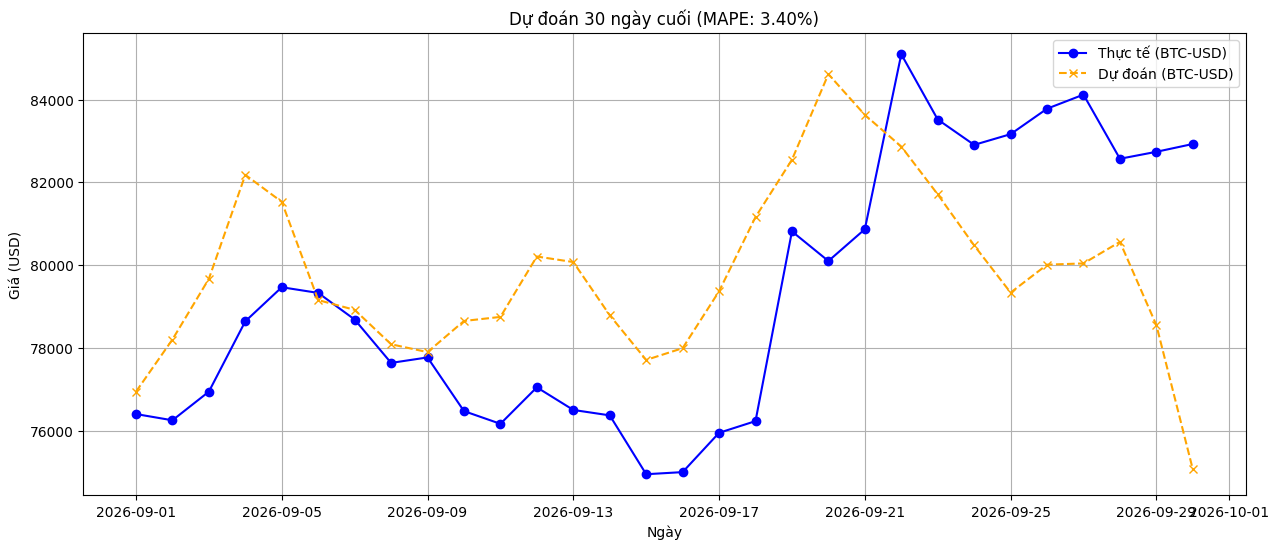

In [13]:
# ========== ĐÁNH GIÁ (REFINED) ==========
# Dự đoán
test_preds_scaled = model.predict(X_test, verbose=0)

# Nghịch đảo chuẩn hóa (Inverse Transform)
# Tạo dummy array có cùng shape với input của scaler
def inverse_transform_low(preds_scaled, scaler, features):
    dummy = np.zeros((len(preds_scaled), len(features)))
    dummy[:, 0] = preds_scaled.flatten()
    inv = scaler.inverse_transform(dummy)
    return inv[:, 0]

y_test_true = train_data['Low'].iloc[-test_days:].values # Đây là bug trong logic cũ, cần lấy từ test_data thực tế
y_test_true = test_data['Low'].values

test_preds_inverse = inverse_transform_low(test_preds_scaled, scaler, features)

# Chỉ số lỗi
mae = mean_absolute_error(y_test_true, test_preds_inverse)
rmse = np.sqrt(mean_squared_error(y_test_true, test_preds_inverse))
mape = np.mean(np.abs((y_test_true - test_preds_inverse) / y_test_true)) * 100

print(f"MAE: {mae:.2f} USD")
print(f"RMSE: {rmse:.2f} USD")
print(f"MAPE: {mape:.2f}%")

# Vẽ biểu đồ
test_dates = test_data.index
plt.figure(figsize=(15, 6))
plt.plot(test_dates, y_test_true, label="Thực tế (BTC-USD)", color='blue', marker='o')
plt.plot(test_dates, test_preds_inverse, label="Dự đoán (BTC-USD)", color='orange', linestyle='--', marker='x')
plt.title(f"Dự đoán 30 ngày cuối (MAPE: {mape:.2f}%)")
plt.xlabel("Ngày")
plt.ylabel("Giá (USD)")
plt.legend()
plt.grid(True)
plt.show()

130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


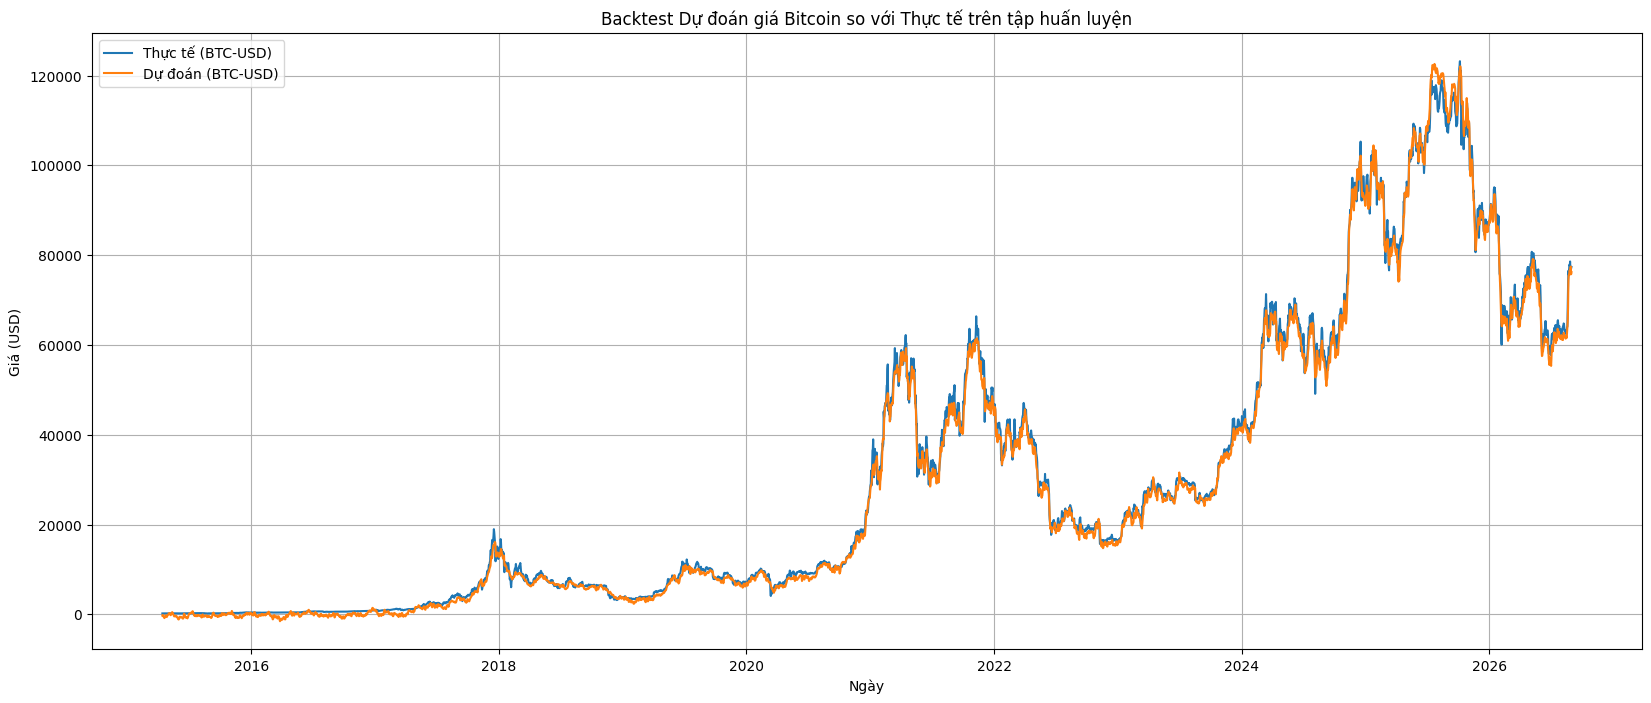

In [14]:
# Backtest
preds = model.predict(X_train)
preds_inverse = scaler.inverse_transform(
    np.hstack([preds, np.zeros((len(preds), len(features)-1))]))[:, 0]
y_true = scaler.inverse_transform(
    np.hstack([y_train.reshape(-1, 1), np.zeros((len(y_train), len(features)-1))]))[:, 0]

plt.figure(figsize=(20, 8))
plt.plot(train_data.index[window_size:], y_true, label="Thực tế (BTC-USD)")
plt.plot(train_data.index[window_size:], preds_inverse, label="Dự đoán (BTC-USD)")
plt.title("Backtest Dự đoán giá Bitcoin so với Thực tế trên tập huấn luyện")
plt.xlabel("Ngày")
plt.ylabel("Giá (USD)")
plt.legend()
plt.grid(True)
plt.show()  # Hiển thị biểu đồ

Forecasting:   0%|          | 0/30 [00:00<?, ?it/s]

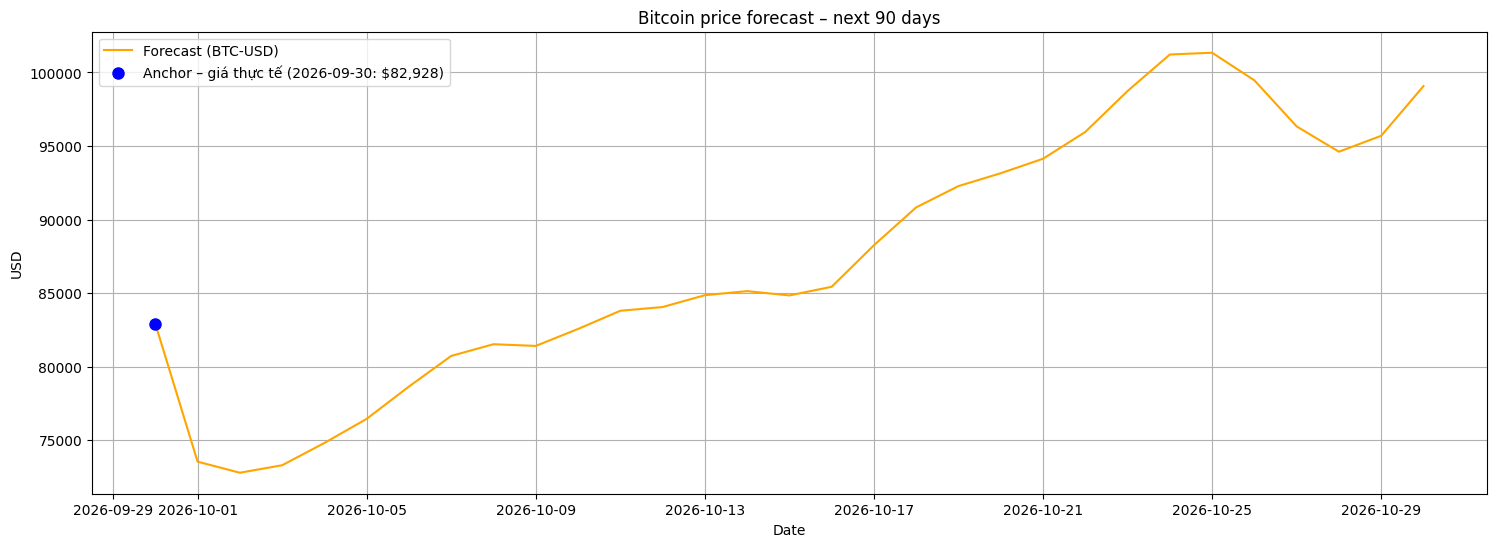

In [15]:
from collections import deque
from tqdm.auto import tqdm

# ==== Forecast Next N days  ===============================================
def forecast_n_days(model, df_scaled, scaler, features, window_size, n_days):
    """
    -> pandas Series dài n_days, index = ngày kế tiếp, giá trị = USD
    """
    n_feat  = len(features)
    # seed queue  shape: (window_size, n_feat)  – giữ nguyên order
    window  = deque(df_scaled[-window_size:], maxlen=window_size)  # O(1) pop/append
    forecasts_scaled = np.empty(n_days, dtype="float32")

    for i in tqdm(range(n_days), desc="Forecasting"):
        # (1) Dự đoán giá Low (đã scaled)
        inp   = np.array(window).reshape(1, window_size, n_feat)   # (1,window,n_feat)
        pred  = model.predict(inp, verbose=0)[0, 0]                 # scalar

        # (2) Lưu kết quả
        forecasts_scaled[i] = pred

        # (3) Tạo vector feature mới cho ngày kế tiếp
        last_row = window[-1].copy()      # shape (n_feat,)
        last_row[0] = pred               # chỉ thay Low, giữ nguyên phần còn lại
        window.append(last_row)          # đẩy vào deque – O(1)

    # ---- inverse_transform về USD ----------------------------------------
    inv = scaler.inverse_transform(
            np.c_[forecasts_scaled, np.zeros((n_days, n_feat-1))]
          )[:, 0]

    future_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1),
                                 periods=n_days, freq="D")
    return pd.Series(inv, index=future_dates, name="Forecast")

# ------------------------------ RUN ---------------------------------------
forecast_90 = forecast_n_days(model,
                              df_scaled.values,
                              scaler,
                              features,
                              window_size,
                              n_days=30)

# ---- Vẽ ---------------------------------------------------------------
# Anchor: điểm giá thực cuối cùng để nối liền với đường forecast
anchor_date  = df.index[-1]
anchor_value = float(df['Low'].iloc[-1])
forecast_anchored = pd.concat([pd.Series([anchor_value], index=[anchor_date]), forecast_90])

plt.figure(figsize=(18,6))
plt.plot(forecast_anchored, label="Forecast (BTC-USD)", color='orange')
plt.plot([anchor_date], [anchor_value],
         'o', color='blue', markersize=8,
         label=f"Anchor – giá thực tế ({anchor_date.date()}: ${anchor_value:,.0f})")
plt.title("Bitcoin Low forecast – next 30 days")
plt.xlabel("Date"); plt.ylabel("USD"); plt.grid(True); plt.legend()
plt.show()


In [16]:
# # Hàm dự đoán và vẽ biểu đồ
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.dates import DateFormatter
# from datetime import timedelta
# import io
# from PIL import Image

# def predict_and_plot(days_to_predict, df, df_scaled, scaler, features, model):
#     window_size = 365
#     num_features = len(features)

#     if len(df_scaled) < window_size:
#         raise ValueError(f"Không đủ dữ liệu: cần ít nhất {window_size} ngày, chỉ có {len(df_scaled)} ngày.")

#     seed = df_scaled.values[-window_size:].flatten().reshape(1, 1, window_size * num_features)
#     predictions_scaled = []
    
#     for _ in range(days_to_predict):
#         pred = model.predict(seed, verbose=0)[0, 0]
#         predictions_scaled.append(pred)
#         next_row = seed[0, 0, -num_features:].copy()
#         next_row[0] = pred
#         seed = np.append(seed[0, 0, num_features:], next_row).reshape(1, 1, window_size * num_features)

#     predictions = scaler.inverse_transform(
#         np.hstack([np.array(predictions_scaled).reshape(-1, 1), np.zeros((days_to_predict, num_features-1))])
#     )[:, 0]

#     # Thêm khoảng tin cậy (±5%)
#     ci_percentage = 0.05  # 5%
#     lower_bound = predictions * (1 - ci_percentage)
#     upper_bound = predictions * (1 + ci_percentage)

#     arr_pred_index = pd.date_range(start=df.index[-1] + timedelta(days=1), periods=days_to_predict, freq='D')
#     forecast_df = pd.DataFrame({
#         'Forecast': predictions,
#         'Lower_Bound': lower_bound,
#         'Upper_Bound': upper_bound
#     }, index=arr_pred_index)

#     result_text = "               Dự đoán / Forecast\n"
#     for date, row in forecast_df.iterrows():
#         result_text += f"{date.strftime('%Y-%m-%d')}  {row['Forecast']:.2f} USD (Khoảng tin cậy: {row['Lower_Bound']:.2f} - {row['Upper_Bound']:.2f} USD) / {date.strftime('%Y-%m-%d')}  {row['Forecast']:.2f} USD (CI: {row['Lower_Bound']:.2f} - {row['Upper_Bound']:.2f} USD)\n"
#     result_text = result_text.rstrip('\n')

#     # Biểu đồ dự đoán với nhãn song ngữ
#     plt.figure(figsize=(15, 5))
#     plt.plot(forecast_df['Forecast'], label='Dự đoán / Forecast (BTC-USD)', marker='o', markersize=5, color='orange')
#     plt.fill_between(forecast_df.index, forecast_df['Lower_Bound'], forecast_df['Upper_Bound'], 
#                      color='orange', alpha=0.3, label='Khoảng tin cậy (±5%) / Confidence Interval (±5%)')
#     plt.title(f"Dự đoán giá Bitcoin cho {len(forecast_df)} ngày tới / Bitcoin Price Forecast for the Next {len(forecast_df)} Days")
#     plt.xlabel("Ngày / Date")
#     plt.ylabel("Giá (USD) / Price (USD)")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
#     buf = io.BytesIO()
#     plt.savefig(buf, format='png', bbox_inches='tight')
#     buf.seek(0)
#     forecast_img = Image.open(buf)
#     plt.close()

#     # Biểu đồ so sánh giá thực tế và dự đoán với nhãn song ngữ
#     # Đã thay đổi từ 'Close' sang 'Low'
#     true_values = df['Low']
#     plt.figure(figsize=(15, 5))
#     plt.plot(true_values, label='Giá thực tế / Actual Price (BTC-USD)', color='blue')
#     plt.plot(forecast_df['Forecast'], label='Dự đoán / Forecast (BTC-USD)', color='orange')
#     plt.fill_between(forecast_df.index, forecast_df['Lower_Bound'], forecast_df['Upper_Bound'], 
#                      color='orange', alpha=0.3, label='Khoảng tin cậy (±5%) / Confidence Interval (±5%)')
#     plt.title("Giá Bitcoin thực tế và dự đoán / Actual and Predicted Bitcoin Prices")
#     plt.xlabel("Ngày / Date")
#     plt.ylabel("Giá (USD) / Price (USD)")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
#     buf = io.BytesIO()
#     plt.savefig(buf, format='png', bbox_inches='tight')
#     buf.seek(0)
#     combined_img = Image.open(buf)
#     plt.close()

#     return result_text, forecast_img, combined_img

In [17]:
# # ==== Precompute Predictions for 1 to 30 Days ====
# # Tính trước dự đoán từ 1 đến 30 ngày
# import os
# os.makedirs('forecast_images', exist_ok=True)
# results = {}
# for days in range(1, 31):
#     result_text, forecast_img, combined_img = predict_and_plot(days, df, df_scaled, scaler, features, model)
#     if result_text and forecast_img and combined_img:
#         results[days] = {
#             'result_text': result_text,
#             'forecast_img': forecast_img,
#             'combined_img': combined_img,
#             'forecast_img_path': os.path.join('forecast_images', f'forecast_{days}.png'),
#             'combined_img_path': os.path.join('forecast_images', f'combined_{days}.png')
#         }
#     else:
#         print(f"Không thể tạo kết quả cho {days} ngày.")

# # ==== Lưu hình ảnh vào đĩa ====
# for days, data in results.items():
#     try:
#         data['forecast_img'].save(data['forecast_img_path'])
#         data['combined_img'].save(data['combined_img_path'])
#         print(f"Đã lưu ảnh cho {days} ngày: {data['forecast_img_path']} và {data['combined_img_path']}")
#     except Exception as e:
#         print(f"Lỗi lưu ảnh cho {days} ngày: {str(e)}")

# # ==== Zip the Forecast Images ====
# folder_to_zip = 'forecast_images'
# zip_output = 'forecast_images.zip'

# with zipfile.ZipFile(zip_output, 'w', zipfile.ZIP_DEFLATED) as zipf:
#     for root, dirs, files in os.walk(folder_to_zip):
#         for file in files:
#             file_path = os.path.join(root, file)
#             zipf.write(file_path, os.path.relpath(file_path, '.'))
#             print(f"Đã thêm file vào zip: {file}")

# print(f"Created zip file: {zip_output}")

In [18]:
# #Lưu kết quả vào CSV
# df_results = pd.DataFrame.from_dict({k: v['result_text'] for k, v in results.items()}, orient='index', columns=['Forecast'])
# df_results.to_csv('precomputed_predictions.csv', index_label='Days')

In [19]:
# # Lưu kết quả vào CSV với Confidence Interval ±5% cho mỗi dự đoán
# import re

# def parse_forecast_text(text):
#     """
#     Parse chuỗi result_text để trích xuất Date, Forecast, Lower_Bound, Upper_Bound.
#     Confidence Interval được tính ±5% của Forecast.
#     """
#     pattern = r"(\d{4}-\d{2}-\d{2})  (\d+\.\d+) USD \(Khoảng tin cậy: (\d+\.\d+) - (\d+\.\d+) USD\) /"
#     matches = re.findall(pattern, text)
#     data = []
#     for match in matches:
#         date, forecast, lower, upper = match
#         forecast_val = float(forecast)
#         lower_val = float(lower)
#         upper_val = float(upper)
#         # Xác nhận CI là ±5%
#         assert abs(lower_val - forecast_val * 0.95) < 1e-2, "Lower bound không khớp ±5%"
#         assert abs(upper_val - forecast_val * 1.05) < 1e-2, "Upper bound không khớp ±5%"
#         data.append({'Date': date, 'Forecast': forecast_val, 'Lower_Bound': lower_val, 'Upper_Bound': upper_val})
#     return pd.DataFrame(data)

# all_data = []
# for days, data in results.items():
#     forecast_df = parse_forecast_text(data['result_text'])
#     all_data.append(forecast_df)

# df_all = pd.concat(all_data)
# df_all.to_csv('precomputed_predictions.csv', index=False)

# print("Đã lưu file 'precomputed_predictions.csv' với các cột: Date, Forecast, Lower_Bound (±5%), Upper_Bound (±5%).")